# Phase 1 Data Engineering (ETL & QUALITY)

Modul 1, 2, 3 - Implementasi

1. Setup Environment

In [28]:
import os
try:
    import pyspark
    print("PySpark already installed.")
except ImportError:
    print("Installing PySpark...")
    os.system('pip install pyspark')

from pyspark.sql import SparkSession
# UPDATED IMPORTS: Added coalesce, regexp_replace for robust cleaning
from pyspark.sql.functions import col, to_date, to_timestamp, count, when, isnan, coalesce, regexp_replace
from pyspark.sql.types import DoubleType, IntegerType

# Inisialisasi Spark Session (Anggap ini koneksi ke Cluster)
# FIX CRITICAL: Tambahin config LEGACY biar to_date gak error kalau format beda
spark = SparkSession.builder \
    .appName("CoffeeShop_DataEngineering") \
    .master("local[*]") \
    .config("spark.sql.caseSensitive", "true") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .config("spark.sql.ansi.enabled", "false") \
    .getOrCreate()

print(f"Spark Version: {spark.version}")

PySpark already installed.
Spark Version: 4.0.1


2. Ingestion & Storage Strategy (Simulasi HDFS)

In [17]:
print("\n Setup Storage Layer (Simulasi HDFS)...")

# Kita bikin struktur folder ala Data Lake
base_dir = "coffee_project_datalake"
raw_dir = f"{base_dir}/raw"
processed_dir = f"{base_dir}/processed"

os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

original_file = "Coffee_Shop_Sales.csv"
target_raw_file = f"{raw_dir}/transactions.csv"

if os.path.exists(original_file):
    os.rename(original_file, target_raw_file)
    print(f" Success: File moved to Simulated HDFS Raw Layer: {target_raw_file}")
else:
    print(f" Warning: File '{original_file}' not found. Pastikan sudah upload ke Colab!")


[MODUL 2] Setup Storage Layer (Simulasi HDFS)...
 Success: File moved to Simulated HDFS Raw Layer: coffee_project_datalake/raw/transactions.csv


3. Cleaning & Type Casting

In [29]:
print("\n Data Cleaning & Quality Control...")

# 1. Load Raw Data
# Gw pake inferSchema=True buat awal, tapi nanti kita enforce tipe datanya
print("Attempting to load data...")
df_raw = spark.read.csv(target_raw_file, header=True, inferSchema=True)

# --- ROBUSTNESS CHECK (Senior Engineer Way) ---
# Cek apakah data terbaca sebagai 1 kolom panjang yang mengandung ';'?
# Ini penanganan error otomatis kalau file aslinya pake delimiter titik koma
first_col = df_raw.columns[0]
if len(df_raw.columns) <= 1 and ";" in first_col:
    print(f" Warning: Dataset terdeteksi menggunakan delimiter ';'. Reloading...")
    df_raw = spark.read.csv(target_raw_file, header=True, inferSchema=True, sep=";")

print("--- Raw Schema (Before Casting) ---")
df_raw.printSchema()

# 2. Type Casting & Cleaning
# Masalah umum: Tanggal sering kebaca string, Harga kebaca string kalau ada simbol mata uang
# Format date di dataset lu: "2023-01-01" (ISO format, aman) ATAU "29/04/2023" (European)

# Pastikan nama kolom tidak ada spasi/karakter aneh sebelum select
# Kita normalisasi nama kolom jadi lowercase biar aman
new_columns = [c.lower().strip() for c in df_raw.columns]
df_raw = df_raw.toDF(*new_columns)

# ROBUST CLEANING STRATEGY
# 1. Date: Coba format yyyy-MM-dd dulu, kalau null coba dd/MM/yyyy
# Berkat config LEGACY, fungsi to_date sekarang return NULL kalau format salah, bukan ERROR.
date_cleaning = coalesce(
    to_date(col("transaction_date"), "yyyy-MM-dd"),
    to_date(col("transaction_date"), "dd/MM/yyyy"),
    to_date(col("transaction_date"), "MM/dd/yyyy") # Jaga-jaga format US
).alias("transaction_date")

# 2. Price: Handle European Decimal (koma jadi titik) sebelum cast
# Replace ',' dengan '.' lalu cast ke Double
price_cleaning = regexp_replace(col("unit_price"), ",", ".").cast(DoubleType())

df_clean = df_raw.select(
    col("transaction_id").cast(IntegerType()),
    date_cleaning,
    col("transaction_time"), # Time kita biarin string dulu atau gabung nanti pas Feature Engineering
    col("transaction_qty").cast(IntegerType()),
    col("store_id").cast(IntegerType()),
    col("store_location"),
    col("product_id").cast(IntegerType()),
    price_cleaning.alias("unit_price"),
    col("product_category"),
    col("product_type"),
    col("product_detail")
)

# 3. Data Quality Checks (Sanity Check)
print("\n--- Data Quality Report ---")

# Cek Null Values per kolom
# FIX: Kita bikin dynamic expression. isnan() hanya boleh untuk tipe Double/Float.
# Untuk Date, String, Int, dll, kita pakai isNull() saja.
missing_exprs = []
for col_name, dtype in df_clean.dtypes:
    # dtype formatnya string, misal: 'int', 'double', 'date', 'string'
    if dtype in ('double', 'float'):
        # Khusus angka desimal, cek NaN DAN Null
        missing_exprs.append(count(when(isnan(col_name) | col(col_name).isNull(), col_name)).alias(col_name))
    else:
        # Untuk tipe lain (Date, Int, String), cukup cek Null
        missing_exprs.append(count(when(col(col_name).isNull(), col_name)).alias(col_name))

df_clean.select(missing_exprs).show()

# Cek Anomaly (Harga negatif atau Qty negatif)
anomaly_count = df_clean.filter((col("unit_price") < 0) | (col("transaction_qty") < 0)).count()
print(f"Jumlah Transaksi Anomali (Minus Price/Qty): {anomaly_count}")

# Kalau ada anomali, kita filter out (Cleaning)
df_final = df_clean.filter((col("unit_price") >= 0) & (col("transaction_qty") > 0))

print("--- Final Schema (Ready for Analysis) ---")
df_final.printSchema()

# Show sample data
print("Sample Data:")
df_final.show(5)

# 4. Save to Processed Layer (Parquet)
# Kenapa Parquet?
# 1. Kompresi tinggi (hemat storage HDFS).
# 2. Columnar storage (query analytic jauh lebih cepat dibanding CSV).
# 3. Menyimpan metadata schema (gak perlu casting ulang pas diload lagi).

output_path = f"{processed_dir}/transactions_cleaned.parquet"
df_final.write.mode("overwrite").parquet(output_path)

print(f" Success: Data bersih disimpan dalam format Parquet di: {output_path}")
print("Phase 1 Complete. Ready for EDA.")


[MODUL 3] Data Cleaning & Quality Control...
Attempting to load data...
⚠️ Warning: Dataset terdeteksi menggunakan delimiter ';'. Reloading...
--- Raw Schema (Before Casting) ---
root
 |-- transaction_id: integer (nullable = true)
 |-- transaction_date: string (nullable = true)
 |-- transaction_time: string (nullable = true)
 |-- transaction_qty: integer (nullable = true)
 |-- store_id: integer (nullable = true)
 |-- store_location: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- unit_price: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- product_type: string (nullable = true)
 |-- product_detail: string (nullable = true)


--- Data Quality Report ---
+--------------+----------------+----------------+---------------+--------+--------------+----------+----------+----------------+------------+--------------+
|transaction_id|transaction_date|transaction_time|transaction_qty|store_id|store_location|product_id|unit_price|product_catego

#  Phase 2: EDA & Batch Processing

Modul 4 (EDA) & Modul 5 (RDD MapReduce)

Setup

In [30]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as _sum, count, desc, split, hour, month, dayofweek
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup Spark (Re-init kalau di script terpisah, atau pakai session yg ada)
spark = SparkSession.builder \
    .appName("CoffeeShop_Phase2") \
    .master("local[*]") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

Load Processed Data

In [31]:
print("\n Loading Cleaned Data from Parquet...")
processed_path = "coffee_project_datalake/processed/transactions_cleaned.parquet"

# Cek apakah file ada (Guard clause)
import os
if not os.path.exists(processed_path):
    print(f" Error: File {processed_path} tidak ditemukan. Jalankan Phase 1 dulu!")
else:
    df = spark.read.parquet(processed_path)
    df.printSchema()
    print(f"Jumlah Data: {df.count()} baris")


 Loading Cleaned Data from Parquet...
root
 |-- transaction_id: integer (nullable = true)
 |-- transaction_date: date (nullable = true)
 |-- transaction_time: string (nullable = true)
 |-- transaction_qty: integer (nullable = true)
 |-- store_id: integer (nullable = true)
 |-- store_location: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- product_category: string (nullable = true)
 |-- product_type: string (nullable = true)
 |-- product_detail: string (nullable = true)

Jumlah Data: 149116 baris


4: Exploratory Data Analisys (EDA)


 Exploratory Data Analysis (Business Insights)...

 Insight 1: Total Omzet per Lokasi 
+---------------+------------------+---------+
| store_location|     total_revenue|total_trx|
+---------------+------------------+---------+
| Hell's Kitchen|236511.17000000307|    50735|
|        Astoria|232243.91000000044|    50599|
|Lower Manhattan| 230057.2500000035|    47782|
+---------------+------------------+---------+



/tmp/ipython-input-2832230522.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf_store, x='store_location', y='total_revenue', palette='viridis')


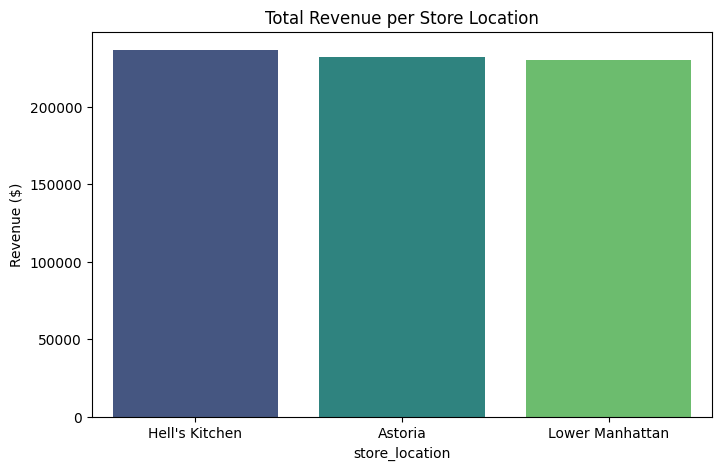


 Insight 2: Pola Jam Sibuk (Peak Hours) 


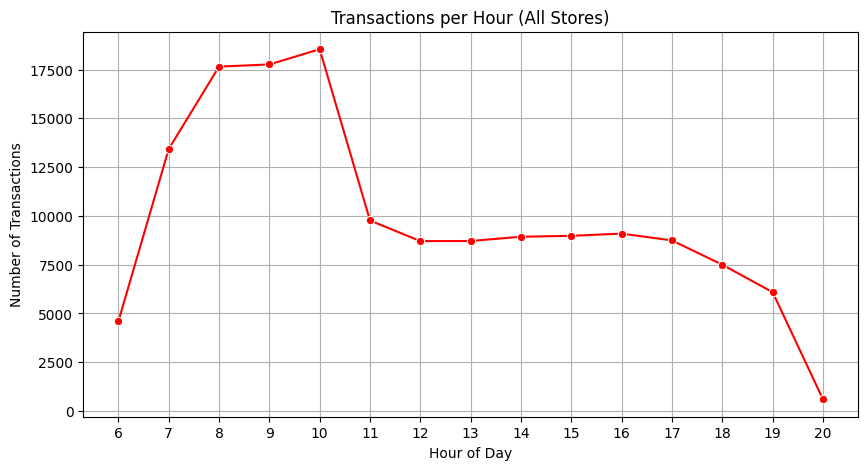


 Insight 3: Produk Paling Laris (Top 5 Qty) 
+-----------------------+---------+
|product_detail         |total_qty|
+-----------------------+---------+
|Earl Grey Rg           |4708     |
|Dark chocolate Lg      |4668     |
|Morning Sunrise Chai Rg|4643     |
|Latte                  |4602     |
|Peppermint Rg          |4564     |
+-----------------------+---------+



In [33]:
print("\n Exploratory Data Analysis (Business Insights)...")

# 1. FEATURE ENGINEERING
# Kita butuh 'Revenue' (Qty * Price) dan 'Hour' dari transaction_time
df_eda = df.withColumn("revenue", col("transaction_qty") * col("unit_price")) \
           .withColumn("hour", split(col("transaction_time"), ":").getItem(0).cast("int"))

# -2. ANALISIS 1: Store Performance (Revenue per Toko)
print("\n Insight 1: Total Omzet per Lokasi ")
store_perf = df_eda.groupBy("store_location") \
    .agg(_sum("revenue").alias("total_revenue"), count("transaction_id").alias("total_trx")) \
    .orderBy(desc("total_revenue"))

store_perf.show()

# Visualisasi (Spark -> Pandas -> Plot)
pdf_store = store_perf.toPandas()

plt.figure(figsize=(8, 5))
sns.barplot(data=pdf_store, x='store_location', y='total_revenue', palette='viridis')
plt.title('Total Revenue per Store Location')
plt.ylabel('Revenue ($)')
plt.show() # Di Colab ini bakal munculin gambar

# 3. ANALISIS 2: Peak Hour Analysis (Jam Sibuk)
print("\n Insight 2: Pola Jam Sibuk (Peak Hours) ")
# Kita lihat pola transaksi berdasarkan jam
hourly_trend = df_eda.groupBy("hour") \
    .count() \
    .orderBy("hour")

pdf_hour = hourly_trend.toPandas()

plt.figure(figsize=(10, 5))
sns.lineplot(data=pdf_hour, x='hour', y='count', marker='o', color='red')
plt.title('Transactions per Hour (All Stores)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.xticks(range(6, 21)) # Jam operasional biasanya 6 pagi - 8 malam
plt.show()

# 4. ANALISIS 3: Top 5 Products
print("\n Insight 3: Produk Paling Laris (Top 5 Qty) ")
top_products = df_eda.groupBy("product_detail") \
    .agg(_sum("transaction_qty").alias("total_qty")) \
    .orderBy(desc("total_qty")) \
    .limit(5)

top_products.show(truncate=False)

5. Batch Processing (MapReduce / RDD)

In [34]:
print("\n Batch Processing dengan RDD (MapReduce Manual)")

# Konversi DataFrame ke RDD
rdd = df_eda.rdd

# Step 1: Mapping
# Row object bisa diakses kayak dictionary atau attribute
mapped_rdd = rdd.map(lambda row: (row.product_category, row.revenue))

# Step 2: Reducing (reduceByKey)
# x = akumulator, y = nilai baru
reduced_rdd = mapped_rdd.reduceByKey(lambda x, y: x + y)

# Step 3: Action (Collect results)
# Hati-hati collect() kalau datanya jutaan kategori! Tapi disini kategori cuma dikit.
results = reduced_rdd.collect()

# Tampilkan Hasil
print("\n Hasil Perhitungan MapReduce (Revenue per Kategori) ")
# Sortir manual pake Python biasa (karena hasilnya udah list lokal)
sorted_results = sorted(results, key=lambda x: x[1], reverse=True)

print(f"{'Category':<20} | {'Total Revenue':>15}")
print("-" * 40)
for category, revenue in sorted_results:
    print(f"{category:<20} | ${revenue:,.2f}")

print("\nPhase 2 Complete. 4 & 5 Done.")


 Batch Processing dengan RDD (MapReduce Manual)

 Hasil Perhitungan MapReduce (Revenue per Kategori) 
Category             |   Total Revenue
----------------------------------------
Coffee               | $269,952.45
Tea                  | $196,405.95
Bakery               | $82,315.64
Drinking Chocolate   | $72,416.00
Coffee beans         | $40,085.25
Branded              | $13,607.00
Loose Tea            | $11,213.60
Flavours             | $8,408.80
Packaged Chocolate   | $4,407.64

Phase 2 Complete. 4 & 5 Done.


# Phase 3: Machine Learning (Clustering)

Modul 6 (Feature Eng), 7 (Modeling), 8 (Tuning), 9 (Eval)

In [35]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as _sum, count, first, hour, split
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Setup Spark
spark = SparkSession.builder \
    .appName("CoffeeShop_Phase3_ML") \
    .master("local[*]") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

# Load Data (Guard Clause)
processed_path = "coffee_project_datalake/processed/transactions_cleaned.parquet"
if not os.path.exists(processed_path):
    sys.exit(" Error: File Parquet tidak ditemukan. Jalankan Phase 1 dulu!")

df = spark.read.parquet(processed_path)
print(f"Data Loaded: {df.count()} rows")

Data Loaded: 149116 rows


6. Spark SQL & Feature Engineering

In [36]:
print("\n Feature Engineering (Creating 'Basket' Data)...")

# 1. Prepare Base Features
# Kita hitung Total Belanja (Revenue) per baris dulu
df_prep = df.withColumn("line_total", col("transaction_qty") * col("unit_price")) \
            .withColumn("hour_str", split(col("transaction_time"), ":").getItem(0).cast("int"))

# 2. AGGREGATION (The Critical Step)
# Kita kelompokkan berdasarkan (Date, Time, Store) -> Ini definisi 1 Customer/Basket
# Kita ambil fitur: Total Item (Qty), Total Bayar (Bill), Jam Transaksi (Hour)
df_basket = df_prep.groupBy("transaction_date", "transaction_time", "store_location") \
    .agg(
        _sum("transaction_qty").alias("basket_qty"),
        _sum("line_total").alias("basket_amount"),
        first("hour_str").alias("hour_of_day")
    )

print(" Sample Basket Data (Customer Level) ")
df_basket.show(5)
print(f"Total Unique Baskets (Customers): {df_basket.count()}")

# 3. Vector Assembling
# MLlib butuh input berupa kolom Vector, bukan kolom terpisah
feature_cols = ["basket_qty", "basket_amount", "hour_of_day"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
df_vector = assembler.transform(df_basket)

# 4. Scaling (StandardScaler)
# K-Means sensitif sama skala. Qty (1-10) vs Amount (3.0 - 50.0) beda range.
# Kita samakan range-nya biar adil.
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_vector)
df_final = scaler_model.transform(df_vector)

print(" Feature Engineering Done. Ready for ML.")


 Feature Engineering (Creating 'Basket' Data)...
 Sample Basket Data (Customer Level) 
+----------------+----------------+--------------+----------+-------------+-----------+
|transaction_date|transaction_time|store_location|basket_qty|basket_amount|hour_of_day|
+----------------+----------------+--------------+----------+-------------+-----------+
|      2023-01-01|        09:53:28|Hell's Kitchen|         1|          3.0|          9|
|      2023-01-01|        11:50:16|       Astoria|         2|          6.0|         11|
|      2023-01-01|        14:03:41|       Astoria|         1|          3.0|         14|
|      2023-01-01|        15:02:04|       Astoria|         2|          8.5|         15|
|      2023-01-01|        19:07:26|Hell's Kitchen|         2|          6.0|         19|
+----------------+----------------+--------------+----------+-------------+-----------+
only showing top 5 rows
Total Unique Baskets (Customers): 116790
 Feature Engineering Done. Ready for ML.


7 & 8 Modeling & Hyperparameter Tuning

In [37]:
print("\n K-Means Clustering & Tuning...")

# Kita cari K terbaik (Jumlah Cluster) pake metode 'Elbow' (SSE) dan 'Silhouette'
# Karena data banyak, kita batasi K=2 sampai K=6 aja biar cepet di Colab
k_values = [2, 3, 4, 5, 6]
silhouette_scores = []
sse_scores = [] # Sum of Squared Errors

print(f"{'K':<5} | {'Silhouette Score':<20} | {'SSE (Cost)':<20}")
print("-" * 50)

best_score = -1
best_k = 2
best_model = None

for k in k_values:
    # Train Model
    kmeans = KMeans(featuresCol="features", k=k, seed=42)
    model = kmeans.fit(df_final)

    # Make Predictions
    predictions = model.transform(df_final)

    # Evaluate (Silhouette Score) - Range -1 s/d 1 (Makin dekat 1 makin bagus)
    evaluator = ClusteringEvaluator()
    silhouette = evaluator.evaluate(predictions)

    # Evaluate (SSE - Cost) - Makin kecil makin bagus (tapi jangan 0)
    sse = model.summary.trainingCost

    silhouette_scores.append(silhouette)
    sse_scores.append(sse)

    print(f"{k:<5} | {silhouette:.4f}{' (Best)' if silhouette > best_score else '' :<13} | {sse:.2f}")

    # Simpan model terbaik berdasarkan Silhouette
    if silhouette > best_score:
        best_score = silhouette
        best_k = k
        best_model = model

print("-" * 50)
print(f" Best K found: {best_k} (Score: {best_score:.4f})")



 K-Means Clustering & Tuning...
K     | Silhouette Score     | SSE (Cost)          
--------------------------------------------------
2     | 0.4011 (Best)       | 258207.14
3     | 0.5156 (Best)       | 175448.93
4     | 0.5140              | 151690.91
5     | 0.5824 (Best)       | 127533.15
6     | 0.6102 (Best)       | 82423.36
--------------------------------------------------
 Best K found: 6 (Score: 0.6102)


9. Evaluation & Interpretation


 Model Interpretation (Business Insight)...
 Profil Karakteristik 6 Tipe Pelanggan (Cluster Centers) 
Cluster    | Avg Qty         | Avg Bill ($)    | Avg Hour       
-----------------------------------------------------------------
Cluster 0  | 2.19            | $6.78           | 15.9           
Cluster 1  | 3.73            | $17.07          | 10.4           
Cluster 2  | 1.00            | $3.05           | 15.9           
Cluster 3  | 1.00            | $3.06           | 9.1            
Cluster 4  | 2.21            | $6.73           | 9.1            
Cluster 5  | 10.50           | $366.97         | 9.9            


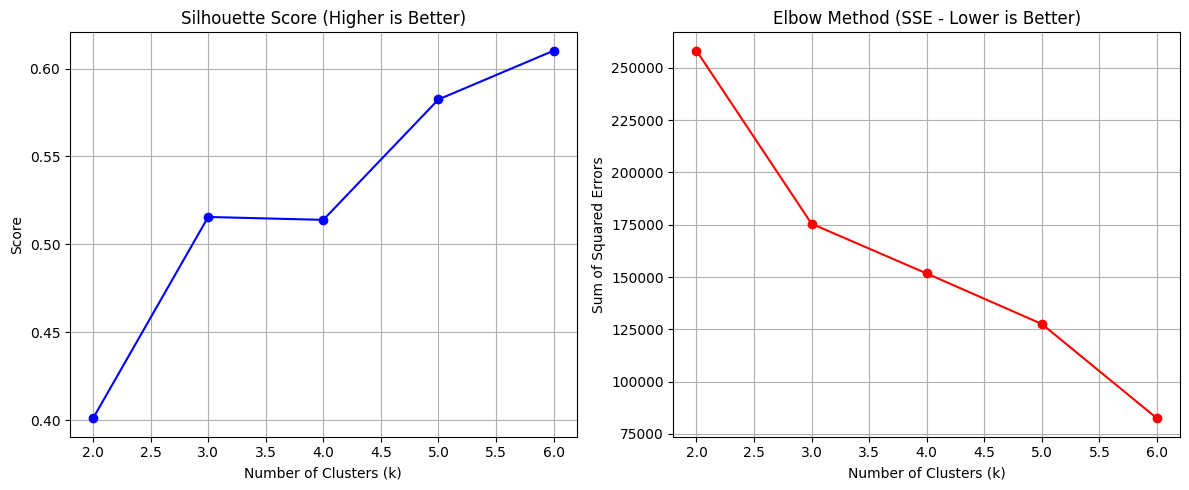

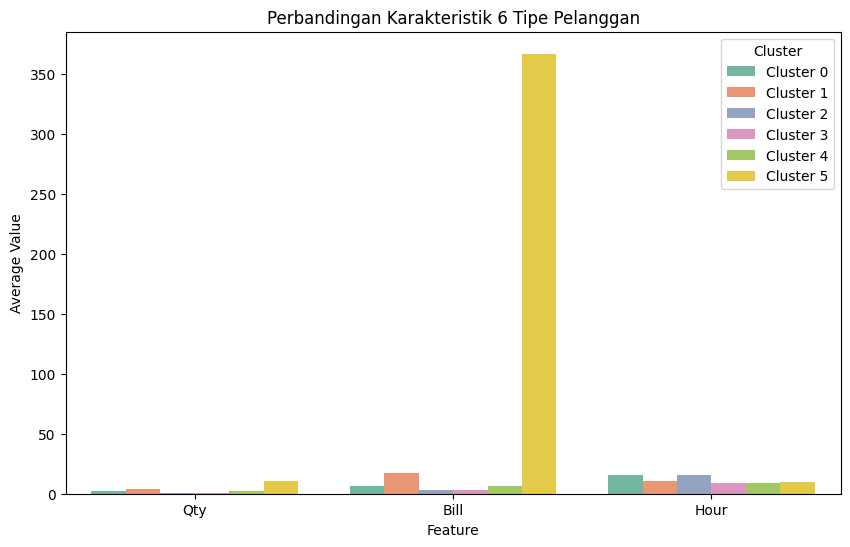


 PROJECT COMPLETE! All phases executed.


In [38]:
print("\n Model Interpretation (Business Insight)...")

# Kita ambil pusat cluster (Centroid) dari model terbaik
centers = best_model.clusterCenters()

# De-Scale Centroid (Balikin ke angka asli biar bisa dibaca manusia)
# Rumus: Original = (Scaled * Std) + Mean
# Kita ambil mean & std dari scaler model tadi
means = scaler_model.mean
stds = scaler_model.std

print(f" Profil Karakteristik {best_k} Tipe Pelanggan (Cluster Centers) ")
print(f"{'Cluster':<10} | {'Avg Qty':<15} | {'Avg Bill ($)':<15} | {'Avg Hour':<15}")
print("-" * 65)

cluster_data = []

for i, center in enumerate(centers):
    # Unscale manual
    orig_qty = (center[0] * stds[0]) + means[0]
    orig_bill = (center[1] * stds[1]) + means[1]
    orig_hour = (center[2] * stds[2]) + means[2]

    print(f"Cluster {i:<2} | {orig_qty:<15.2f} | ${orig_bill:<14.2f} | {orig_hour:<15.1f}")

    cluster_data.append({
        'Cluster': f'Cluster {i}',
        'Qty': orig_qty,
        'Bill': orig_bill,
        'Hour': orig_hour
    })

# Visualisasi Evaluasi (Elbow Plot & Silhouette)
plt.figure(figsize=(12, 5))

# Plot 1: Silhouette Score
plt.subplot(1, 2, 1)
plt.plot(k_values, silhouette_scores, marker='o', color='blue')
plt.title('Silhouette Score (Higher is Better)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.grid(True)

# Plot 2: SSE (Elbow Method)
plt.subplot(1, 2, 2)
plt.plot(k_values, sse_scores, marker='o', color='red')
plt.title('Elbow Method (SSE - Lower is Better)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors')
plt.grid(True)

plt.tight_layout()
plt.show()

# Visualisasi Cluster Profile (Bar Chart)
df_cluster_res = pd.DataFrame(cluster_data)
df_cluster_melt = df_cluster_res.melt(id_vars="Cluster", var_name="Feature", value_name="Value")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_cluster_melt, x="Feature", y="Value", hue="Cluster", palette="Set2")
plt.title(f'Perbandingan Karakteristik {best_k} Tipe Pelanggan')
plt.ylabel('Average Value')
plt.show()

print("\n PROJECT COMPLETE! All phases executed.")